In [3]:
import signac
import sys
import os
import numpy as np
import pandas as pd

from utils.molec_class_files import esolvs
from Build_GPs.utils.signac import get_signac_results, save_signac_results
from Build_GPs.utils.id_new_samples import new_samples_vle, find_pareto, new_samples_ld, check_mse_10
from Build_GPs.utils.models import get_best_models
from Build_GPs.utils.plot import plot_gp_examples
import pickle

from fffit.fffit.utils import values_real_to_scaled, values_scaled_to_real

2025-06-24 09:54:08.548776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750773248.570452  332671 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750773248.576646  332671 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750773248.594004  332671 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750773248.594022  332671 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750773248.594024  332671 computation_placer.cc:177] computation placer alr

In [ ]:


os.chdir("/scratch365/mcarlozo/ES-FFO/Build_GPs")
str = "DMSO"
#Set iters to analyze and properties to analyze
iters = [1]  # Change me as needed
property_names = ["liq_density"]  # Change me as needed
mol_names = [str] # ["EG", "Gly", "ACN", "MeOH", "DMSO", "THF", "DCM", "DEC", "DMF"] Change me as needed


#Set seeds and preferences
cl_shuffle_seed = 1  # classifier
gp_shuffle_seed = 42  # GP seed
dist_seed = 1  # Distance seed
mse_less_10_thresh = 25
save_csv = True
save_fig = True
verbose = True


##############################################################################
##############################################################################
#Get Project
iter_type = "ld_iters"
project = signac.get_project(iter_type)
molec_dict = esolvs.make_dict(mol_names)

# Save DataFrame of all molecule data for each iteration
df_all_molec = get_signac_results(project, molec_dict, property_names)
# df_all_molec = save_signac_results(df_all_molec, iter_type, save_csv)

# models_molecs = get_best_models(df_all_molec, molec_dict, iter_type, gp_shuffle_seed)
# plot_gp_examples(df_all_molec, molec_dict, iter_type, gp_shuffle_seed, save_fig)

#Check the MSE of the new samples
mse_less10 = check_mse_10(df_all_molec, molec_dict, mse_less_10_thresh, dist_seed, save_csv)
#Find the next samples to run if fewer than 25 samples have MSE less than 10
# for key, value in mse_less10.items():
#     if len(value) >= mse_less_10_thresh:
#         print(f"{key} : {len(value)} samples have MSE less than {mse_less_10_thresh}. Proceed to VLE.")
#     else:
#         print(f"{key} : Total samples with MSE less than {mse_less_10_thresh}, {value}")
#         next_samples = new_samples_ld(df_all_molec, molec_dict, verbose, save_fig, cl_shuffle_seed, gp_shuffle_seed, dist_seed)

[[0.07998605 0.49931265 0.38074406 0.94687708 0.05504681 0.23965269
  0.73316992 0.77102145 0.03348057]
 [0.68566363 0.51553526 0.34419244 0.82986649 0.01174596 0.70892662
  0.23218145 0.54527598 0.01645409]
 [0.85768609 0.19382739 0.63099724 0.91091377 0.9802736  0.85580119
  0.33176278 0.17906474 0.02759198]
 [0.92616045 0.14770967 0.69813322 0.21727056 0.9339933  0.42341719
  0.42146736 0.97614743 0.0383325 ]]


/tmp/ipykernel_332671/408119601.py:132: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=16)


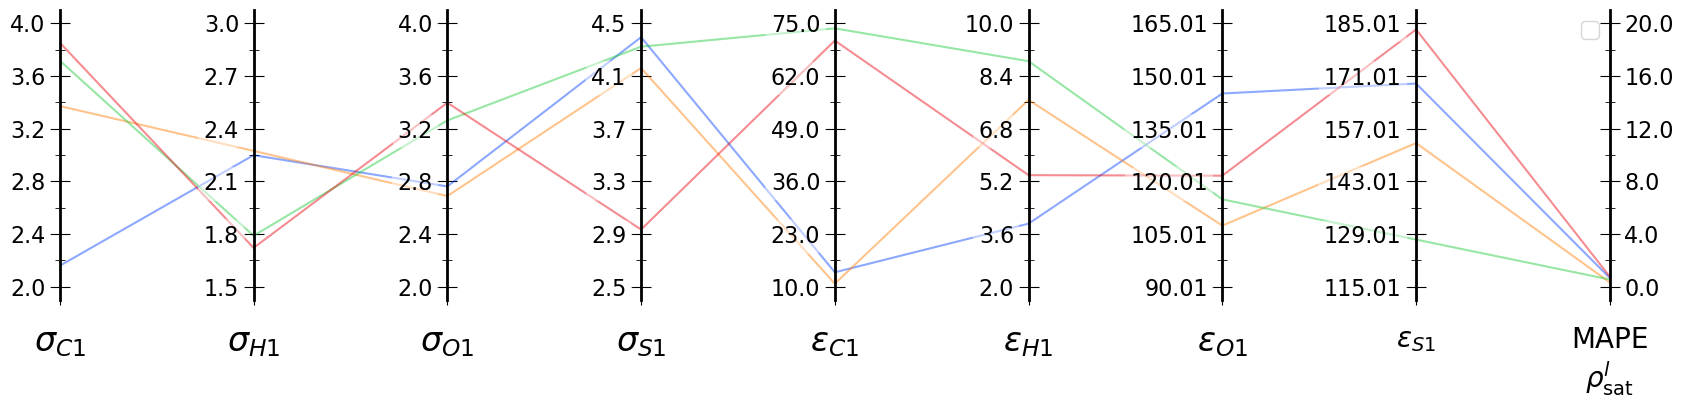

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatch
import seaborn
from matplotlib import ticker

str = "DMSO"
mol_names = [str] # ["EG", "Gly", "ACN", "MeOH", "DMSO", "THF", "DCM", "DEC", "DMF"] Change me as needed

os.chdir("/scratch365/mcarlozo/ES-FFO/")
molec_dict = esolvs.make_dict(mol_names)
data_class = molec_dict[str]
matplotlib.rc("font", family="sans-serif")
matplotlib.rc("font", serif="Arial")

NM_TO_ANGSTROM = 10
K_B = 0.008314 # J/MOL K
KJMOL_TO_K = 1.0 / K_B

def set_ticks_for_axis(ax, param_bounds, nticks):
    """Set the tick positions and labels on y axis for each plot

    Tick positions based on normalised data
    Tick labels are based on original data
    """
    min_val, max_val = param_bounds
    step = (max_val - min_val) / float(nticks-1)
    tick_labels = [round(min_val + step * i, 2) for i in range(nticks)]
    ticks = np.linspace(0, 1.0, nticks)
    ax.yaxis.set_ticks(ticks)
    ax.set_yticklabels(tick_labels, fontsize=16)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.tick_params("y", direction="inout", which="both", length=7)
    ax.tick_params("y", which="major", length=14)
    ax.tick_params("x", pad=15) 

# ID the top ten by lowest average MAPE
#Get params < 10
df = pd.read_csv("Build_GPs/analysis/old" + str + "/ld_iters/mse-less10-full.csv", header = 0, index_col=0)
# print(df.head())

seaborn.set_palette('bright', n_colors=len(df))
data = df[list(data_class.param_names)].values
data = values_real_to_scaled(data, data_class.param_bounds)
result_bounds = np.array([[0, 20]])
results = values_real_to_scaled(df[["mapd"]].values, result_bounds)
param_bounds = data_class.param_bounds
indx_mid = int(len(data_class.param_names) / 2)
param_bounds[:indx_mid] = param_bounds[:indx_mid] * NM_TO_ANGSTROM
param_bounds[indx_mid:] = param_bounds[indx_mid:] * KJMOL_TO_K

data = np.hstack((data, results))
bounds = np.vstack((param_bounds, result_bounds))

print(data)
# print(bounds)

col_names = []
for name in data_class.param_names:
    latex_name = lambda s: fr"$\{s.split('_',1)[0]}_{{{s.split('_',1)[1]}}}$" if '_' in s else fr"${s}$"
    col_names.append(latex_name(name))
col_names += ["MAPE\n" + r"$\rho^l_{\mathrm{sat}}$"]
# print("Column names: ", col_names)
n_axis = len(col_names)
assert data.shape[1] == n_axis
x_vals = [i for i in range(n_axis)]

# Create (N-1) subplots along x axis
fig, axes = plt.subplots(1, n_axis-1, sharey=False, figsize=(20,5))

# print(data)
# Plot each row
for i, ax in enumerate(axes):
    for line in data:
        # print(x_vals, line)
        ax.plot(x_vals, line, alpha=0.45)
    ax.set_xlim([x_vals[i], x_vals[i+1]])

for dim, ax in enumerate(axes):
    ax.xaxis.set_major_locator(ticker.FixedLocator([dim]))
    set_ticks_for_axis(ax, bounds[dim], nticks=6)
    if dim < 10:
        ax.set_xticklabels([col_names[dim]], fontsize=24)
    else:
        ax.set_xticklabels([col_names[dim]], fontsize=20)
    ax.set_ylim(-0.05,1.05)
    # Add white background behind labels
    for label in ax.get_yticklabels():
        label.set_bbox(
            dict(
                facecolor='white',
                edgecolor='none',
                alpha=0.45,
                boxstyle=mpatch.BoxStyle("round4")
            )
        )
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_linewidth(2.0)

ax = axes[-1]
ax.xaxis.set_major_locator(ticker.FixedLocator([n_axis-2, n_axis-1]))
ax.set_xticklabels([col_names[-2], col_names[-1]], fontsize=20)

ax = plt.twinx(axes[-1])
ax.set_ylim(-0.05, 1.05)
set_ticks_for_axis(ax, bounds[-1], nticks=6)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_linewidth(2.0)

# Add gaff
# df_gaff=pd.read_csv("../../run/gaff/results.csv")
# mape_gaff=[]
# for i in range(df_gaff["temperature"].shape[0]):
#     ape=[]
#     ape.append(np.abs(df_gaff["liq_density"][i]-data_class.expt_liq_density[df_gaff["temperature"][i]])/data_class.expt_liq_density[df_gaff["temperature"][i]])
# mape_gaff.append(np.mean(ape))

# print("GAFF MAPEs: ", mape_gaff)
# ax.plot(x_vals[-1], mape_gaff[-1]*100/bounds[-1][1], markersize=12, color="gray", marker="s", alpha=0.5, clip_on=False, zorder=200,label="GAFF")
# ax.plot(x_vals[-2], mape_gaff[-2]*100/bounds[-2][1], markersize=12, color="gray", marker="s", alpha=0.5, clip_on=False, zorder=200)
# ax.plot(x_vals[-3], mape_gaff[-3]*100/bounds[-3][1], markersize=12, color="gray", marker="s", alpha=0.5, clip_on=False, zorder=200)
# ax.plot(x_vals[-4], mape_gaff[-4]*100/bounds[-4][1], markersize=12, color="gray", marker="s", alpha=0.5, clip_on=False, zorder=200)


# Remove space between subplots
plt.subplots_adjust(wspace=0, bottom=0.3)
plt.legend(fontsize=16)
#plt.tight_layout()
#fig.subplots_adjust(left=0, right=50, bottom=0, top=25)

# fig.savefig("pdfs/fig_r50-parallel.png",dpi=360)





In [30]:
import signac
import sys
import os
import numpy as np
import pandas as pd

from utils.molec_class_files import esolvs
from Build_GPs.utils.id_new_samples import new_samples_vle, find_pareto, new_samples_ld, check_mse_10
from Build_GPs.utils.models import get_best_models
from Build_GPs.utils.plot import plot_gp_examples

os.chdir("/scratch365/mcarlozo/ES-FFO/Build_GPs")

#Set iters to analyze and properties to analyze
mol_names = ["R125"] # Change me as needed
molec_dict = esolvs.make_dict(mol_names)
#Set seeds and preferences
cl_shuffle_seed = 1  # classifier
gp_shuffle_seed = 42  # GP seed
dist_seed = 1  # Distance seed
mse_less_10_thresh = 25
save_csv = True
save_fig = True
verbose = True
iter = 4

In [ ]:
# iter_type = "vle_iters"
# property_names = ["liq_density", "vap_density", "Pvap", "Hvap"]
iter_type = "ld_iters"
property_names = ["liq_density"]

In [ ]:
df_all = pd.DataFrame()
for i in range(1,iter+1):
    file = f"analysis/R125/{iter_type}/iter-{i}/results.csv"
    df = pd.read_csv(file, index_col=0, header=0)
    df["iter"] = i
    if i == 1:
        df_all = df
    else:
        df_all = pd.concat([df_all, df], ignore_index=True)

if "density" in df_all.columns:
    df_all.rename(columns={"density": "liq_density"}, inplace=True)
if "Hvap" in property_names:
    df_all["Hvap"] = df_all["Hvap"] * 1000/molec_dict["R125"].molecular_weight  # Convert to J/mol
df_all_molec = {"R125":df_all}

In [ ]:
models_molecs = get_best_models(df_all_molec, molec_dict, iter_type, gp_shuffle_seed)
# plot_gp_examples(df_all_molec, molec_dict, iter_type, gp_shuffle_seed, save_fig)

In [ ]:
#Check VLE
#Check pareto efficient samples for each molecule to see if there is one with < 5% error in all properties
# all_final_params = find_pareto(df_all_molec, molec_dict, property_names)
# for key, value in all_final_params.items():
#     #If there are, we have the final parameters
#     if len(value) > 0:
#         print(f"{key}: Final parameters:")
#         print(value)
#     #Otherwise we need to move to the next iteration
#     else:
#         print(f"{key} : No final parameters found. Move to iteration {max(iters) + 1}")
#         next_samples = new_samples_vle(df_all_molec, molec_dict, verbose, False, gp_shuffle_seed, dist_seed)

#Check LD
#Check the MSE of the new samples
mse_less10 = check_mse_10(df_all_molec, molec_dict, mse_less_10_thresh, dist_seed, save_csv)
#Find the next samples to run if fewer than 25 samples have MSE less than 10
print(mse_less10["R125"])
for key, value in mse_less10.items():
    if len(value) >= mse_less_10_thresh:
        print(f"{key} : {len(value)} samples have MSE less than {mse_less_10_thresh}. Proceed to VLE.")
    else:
        print(f"{key} : Total samples with MSE less than {mse_less_10_thresh}, {value}")
        next_samples = new_samples_ld(df_all_molec, molec_dict, verbose, save_fig, cl_shuffle_seed, gp_shuffle_seed, dist_seed)